# EE-568 — Applied Project 2: RLHF

## Goal of this notebook
This notebook implements the first step of the RLHF pipeline: finding two policies of different quality for a given environment.

We need:
- **π₁** — an *excellent* policy that reliably achieves the maximum possible reward
- **π₂** — a *mediocre* policy that consistently achieves roughly half the maximum reward

## Conditions for a good π₁
- Mean reward close to the environment maximum
- Low standard deviation => it should be consistently excellent, not just occasionally lucky

## Conditions for a good π₂
- Mean reward around half the environment maximum
- **Low standard deviation** => hardest condition to satisfy
- Must be clearly worse than π₁ so that the preference labeling formula produces a meaningful signal

## Why std matters for π₂
If π₂ sometimes performs as well as π₁, the preference label becomes a coin flip (probability ≈ 0.5),
providing no useful learning signal. We need π₂ to be *consistently* mediocre.

## What we tried
- **CartPole-v1**: rejected — the policy learns too fast, no stable mediocre zone exists
- **Acrobot-v1**: selected — wider learning curve, genuine stable mediocre zone around 40,000–45,000 training steps

In [2]:

!pip install stable-baselines3[extra] --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.1 MB/s eta 0:00:00


In [3]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
import numpy as np
import os
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
save_path = "/content/drive/MyDrive/Colab Notebooks/EE-568-RL-Applied-Project-2/outputs/checkpoints"
os.makedirs(save_path, exist_ok=True)

# CartPole


In [ ]:
env = gym.make("CartPole-v1")

checkpoints = [2_000, 4_000, 6_000, 8_000, 10_000, 12_000, 15_000, 20_000]
results = []

for timesteps in checkpoints:
    model = PPO("MlpPolicy", env, verbose=0, device="cpu", seed=0)
    model.learn(total_timesteps=timesteps)

    mean_reward, std_reward = evaluate_policy(
        model,
        env,
        n_eval_episodes=100,
        deterministic=True
    )

    results.append((timesteps, mean_reward, std_reward))
    print(f"{timesteps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    model.save(os.path.join(save_path, f"cartpole_{timesteps}steps"))

2000 steps: 173.2 +/- 140.4
4000 steps: 347.9 +/- 155.8
6000 steps: 289.7 +/- 148.2
8000 steps: 415.7 +/- 117.5
10000 steps: 431.8 +/- 97.5
12000 steps: 432.6 +/- 87.7
15000 steps: 372.4 +/- 105.5
20000 steps: 497.6 +/- 14.2


## Seed 0 fine-grained sweep

1024 steps: 110.9 +/- 46.3
2048 steps: 128.3 +/- 47.3
3072 steps: 125.3 +/- 34.4
4096 steps: 105.8 +/- 31.1
5120 steps: 86.8 +/- 25.3
6144 steps: 113.0 +/- 33.8
7168 steps: 128.4 +/- 40.6
8192 steps: 127.9 +/- 43.8
9216 steps: 146.4 +/- 46.3
10240 steps: 173.8 +/- 78.0
11264 steps: 213.3 +/- 69.0
12288 steps: 204.9 +/- 63.7
13312 steps: 297.7 +/- 120.4
14336 steps: 286.1 +/- 90.7
15360 steps: 500.0 +/- 0.2
Policy is now too good at 15360 steps, stopping


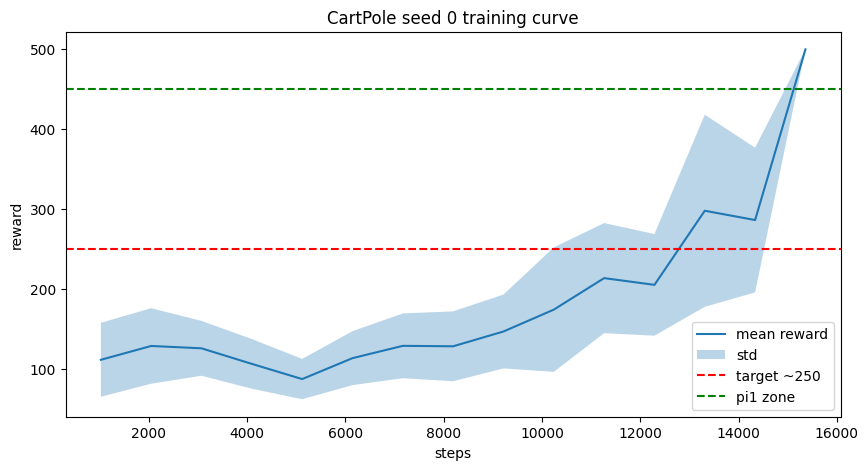

In [8]:
env_train = gym.make("CartPole-v1")
env_eval = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(250, color="red", linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 0 training curve")
plt.legend()
plt.show()

Finished silent training to 11264 steps
11392 steps: -185.9 +/- 160.1
11520 steps: -143.8 +/- 130.6
Too good, stopping


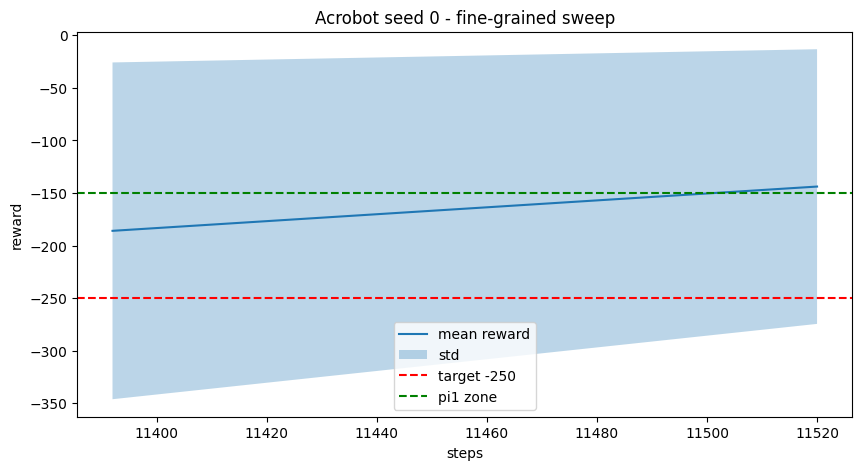

In [10]:
import matplotlib.pyplot as plt

env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

# train silently to the interesting zone
model.learn(total_timesteps=11264, reset_num_timesteps=True)
total_steps = 11264
print(f"Finished silent training to {total_steps} steps")

# fine-grained sweep from 11264 onwards
for _ in range(0, 2_000, 128):
    model.learn(
        total_timesteps=128,
        reset_num_timesteps=False
    )
    total_steps += 128
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print("Too good, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-250, color="red", linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 0 - fine-grained sweep")
plt.legend()
plt.show()

## Seed 1 fine-grained sweep

1024 steps: 63.4 +/- 24.3
2048 steps: 62.1 +/- 15.4
3072 steps: 83.7 +/- 28.8
4096 steps: 108.3 +/- 43.5
5120 steps: 104.9 +/- 42.1
6144 steps: 139.6 +/- 62.0
7168 steps: 127.2 +/- 54.8
8192 steps: 103.1 +/- 33.3
9216 steps: 140.2 +/- 64.3
10240 steps: 188.8 +/- 79.1
11264 steps: 186.0 +/- 72.6
12288 steps: 219.1 +/- 83.2
13312 steps: 236.2 +/- 79.4
14336 steps: 264.1 +/- 76.6
15360 steps: 499.2 +/- 7.0
Policy is now too good at 15360 steps, stopping


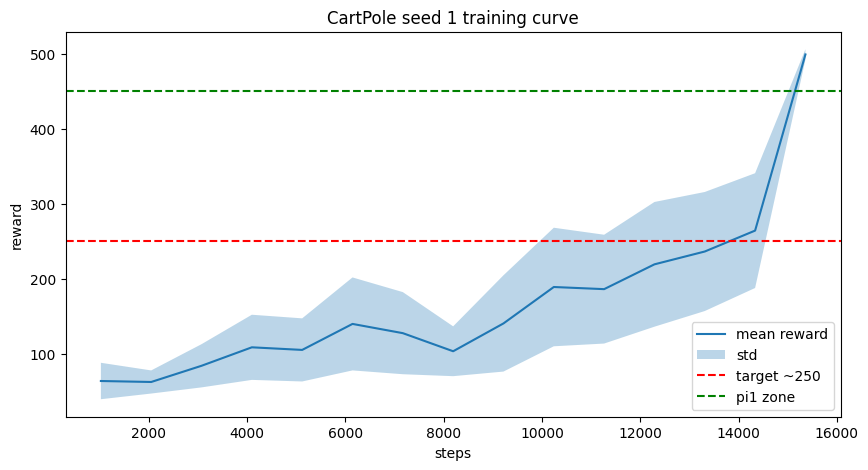

In [11]:
env_train = gym.make("CartPole-v1")
env_eval = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=1,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(250, color="red", linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 1 training curve")
plt.legend()
plt.show()

## Seed 2 fine-grained sweep

1024 steps: 84.8 +/- 32.9
2048 steps: 85.1 +/- 47.4
3072 steps: 142.6 +/- 79.3
4096 steps: 147.9 +/- 77.5
5120 steps: 141.5 +/- 74.5
6144 steps: 121.5 +/- 71.1
7168 steps: 100.5 +/- 48.9
8192 steps: 143.8 +/- 100.2
9216 steps: 99.8 +/- 48.1
10240 steps: 130.3 +/- 72.4
11264 steps: 168.1 +/- 99.8
12288 steps: 177.2 +/- 94.1
13312 steps: 214.4 +/- 105.1
14336 steps: 236.3 +/- 92.4
15360 steps: 297.2 +/- 109.0
16384 steps: 485.8 +/- 43.1
Policy is now too good at 16384 steps, stopping


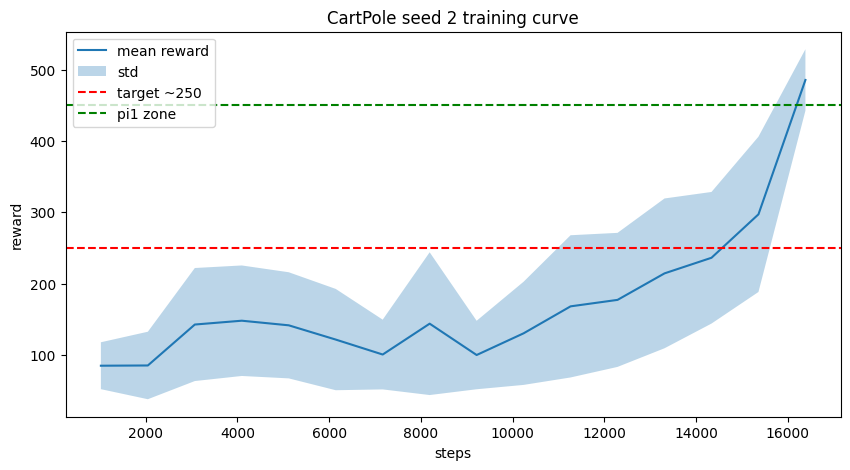

In [12]:
env_train = gym.make("CartPole-v1")
env_eval = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=2,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(250, color="red", linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 2 training curve")
plt.legend()
plt.show()

## Seed 3 fine-grained sweep

1024 steps: 103.1 +/- 45.3
2048 steps: 79.0 +/- 33.8
3072 steps: 76.1 +/- 27.5
4096 steps: 107.2 +/- 52.5
5120 steps: 115.1 +/- 55.4
6144 steps: 135.2 +/- 75.7
7168 steps: 144.1 +/- 90.2
8192 steps: 141.2 +/- 74.3
9216 steps: 150.0 +/- 91.5
10240 steps: 176.9 +/- 112.4
11264 steps: 166.9 +/- 100.1
12288 steps: 161.3 +/- 100.1
13312 steps: 176.9 +/- 100.9
14336 steps: 202.4 +/- 78.3
15360 steps: 272.1 +/- 105.9
16384 steps: 337.6 +/- 113.6
17408 steps: 391.6 +/- 122.0
18432 steps: 311.8 +/- 102.9
19456 steps: 324.3 +/- 129.1
20480 steps: 358.8 +/- 122.0
21504 steps: 425.2 +/- 96.5
22528 steps: 494.9 +/- 19.7
Policy is now too good at 22528 steps, stopping


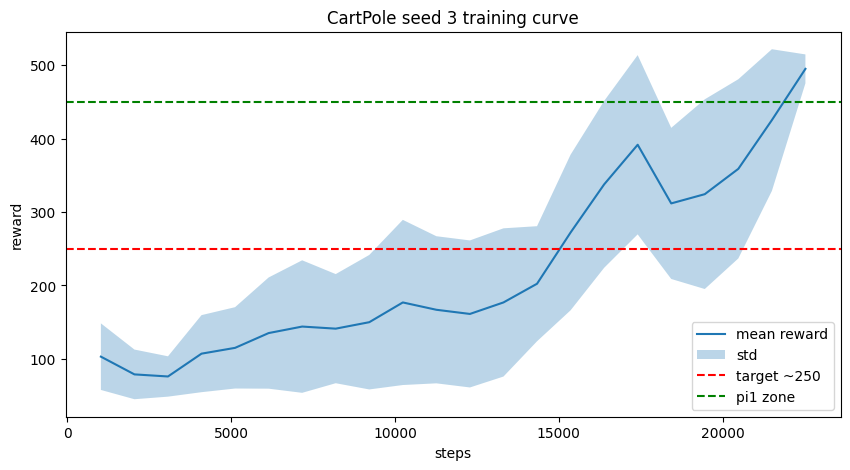

In [13]:
env_train = gym.make("CartPole-v1")
env_eval = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=3,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(250, color="red", linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 3 training curve")
plt.legend()
plt.show()

## Seed 4 fine-grained sweep

1024 steps: 89.6 +/- 31.1
2048 steps: 109.3 +/- 40.4
3072 steps: 102.2 +/- 49.8
4096 steps: 89.4 +/- 36.1
5120 steps: 80.9 +/- 23.3
6144 steps: 93.4 +/- 39.6
7168 steps: 133.2 +/- 55.7
8192 steps: 127.4 +/- 58.8
9216 steps: 141.9 +/- 56.7
10240 steps: 154.2 +/- 61.1
11264 steps: 171.6 +/- 63.0
12288 steps: 203.7 +/- 60.8
13312 steps: 266.0 +/- 80.5
14336 steps: 350.8 +/- 75.1
15360 steps: 392.5 +/- 73.5
16384 steps: 495.8 +/- 17.1
Policy is now too good at 16384 steps, stopping


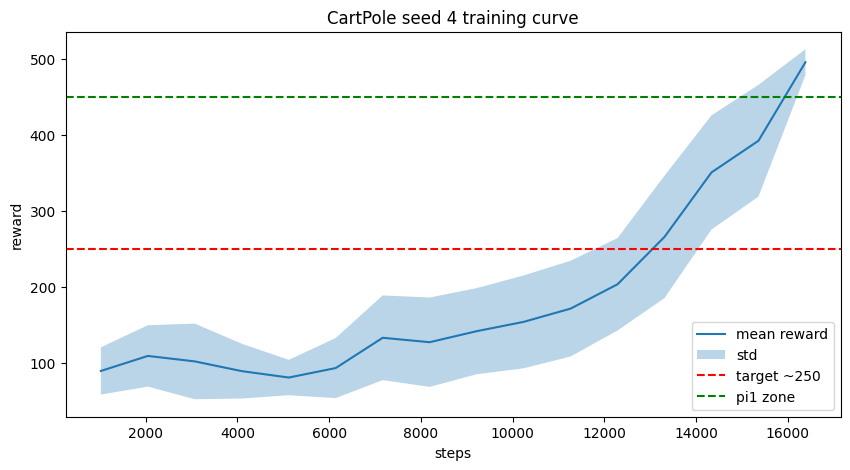

In [14]:
env_train = gym.make("CartPole-v1")
env_eval = gym.make("CartPole-v1")

checkpoint_interval = 1024
steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=4,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 450:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(250, color="red", linestyle="--", label="target ~250")
plt.axhline(450, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("CartPole seed 4 training curve")
plt.legend()
plt.show()

# Acrobot


In [ ]:
env_acrobot = gym.make("Acrobot-v1")
checkpoints = [5_000, 10_000, 20_000, 40_000, 60_000, 80_000, 100_000]
results_acrobot = []

for timesteps in checkpoints:
    model = PPO("MlpPolicy", env_acrobot, verbose=0, device="cpu", seed=0)
    model.learn(total_timesteps=timesteps)
    mean_reward, std_reward = evaluate_policy(
        model,
        env_acrobot,
        n_eval_episodes=100,
        deterministic=True
    )
    results_acrobot.append((timesteps, mean_reward, std_reward))
    print(f"{timesteps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

5000 steps: -500.0 +/- 0.0
10000 steps: -500.0 +/- 0.0
20000 steps: -500.0 +/- 0.0
40000 steps: -178.0 +/- 51.6
60000 steps: -80.6 +/- 22.9
80000 steps: -92.1 +/- 45.4
100000 steps: -94.5 +/- 52.9


## Seed 0 fine-grained sweep

1024 steps: -500.0 +/- 0.0
2048 steps: -500.0 +/- 0.0
3072 steps: -500.0 +/- 0.0
4096 steps: -143.2 +/- 25.3
Policy is now too good at 4096 steps, stopping


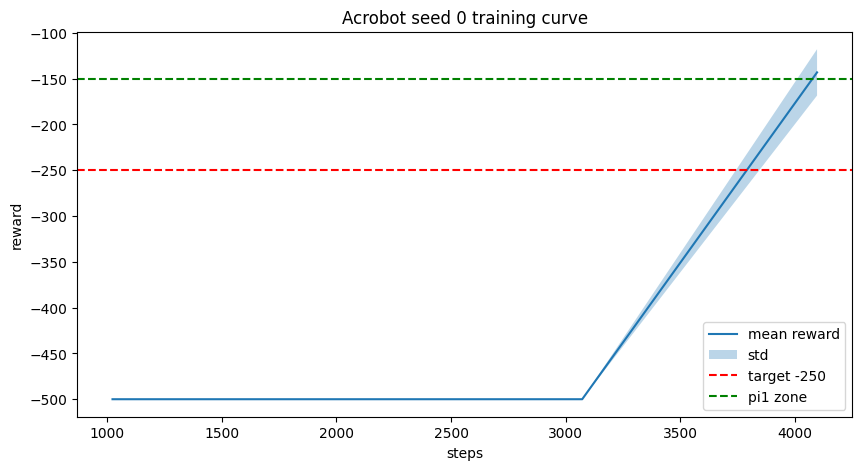

In [16]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

env_train.reset(seed=0)
env_eval.reset(seed=10_000)

checkpoint_interval = 1024

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-250, color="red", linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 0 training curve")
plt.legend()
plt.show()

Finished silent training to 3072 steps
3200 steps: -268.7 +/- 150.5
3328 steps: -157.2 +/- 63.1
3456 steps: -146.1 +/- 45.6
Too good, stopping


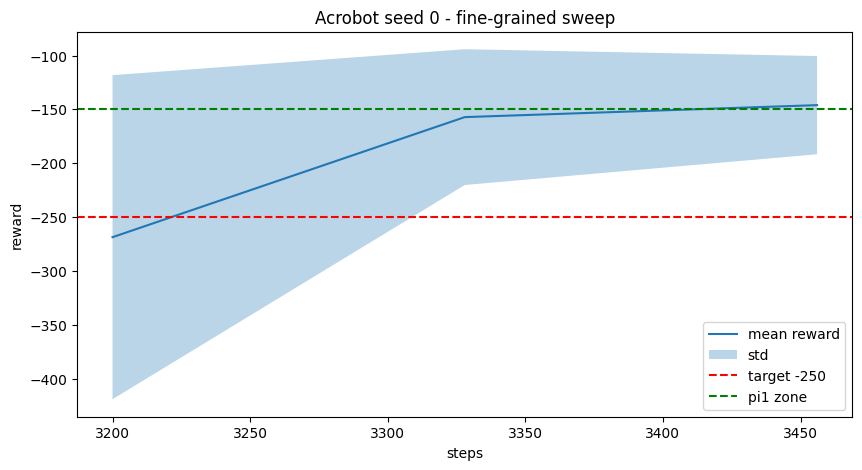

In [17]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

env_train.reset(seed=0)
env_eval.reset(seed=10_000)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

# train silently to the interesting zone
model.learn(total_timesteps=3_072, reset_num_timesteps=True)
total_steps = 3_072
print(f"Finished silent training to {total_steps} steps")

# fine-grained sweep from 3072 onwards
for _ in range(0, 2_000, 128):
    model.learn(
        total_timesteps=128,
        reset_num_timesteps=False
    )
    total_steps += 128
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print("Too good, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-250, color="red", linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 0 - fine-grained sweep")
plt.legend()
plt.show()

## Seed 1 fine-grained sweep

1024 steps: -500.0 +/- 0.0
2048 steps: -500.0 +/- 0.0
3072 steps: -500.0 +/- 0.0
4096 steps: -500.0 +/- 0.0
5120 steps: -500.0 +/- 0.0
6144 steps: -500.0 +/- 0.0
7168 steps: -374.6 +/- 171.9
8192 steps: -124.5 +/- 105.8
Policy is now too good at 8192 steps, stopping


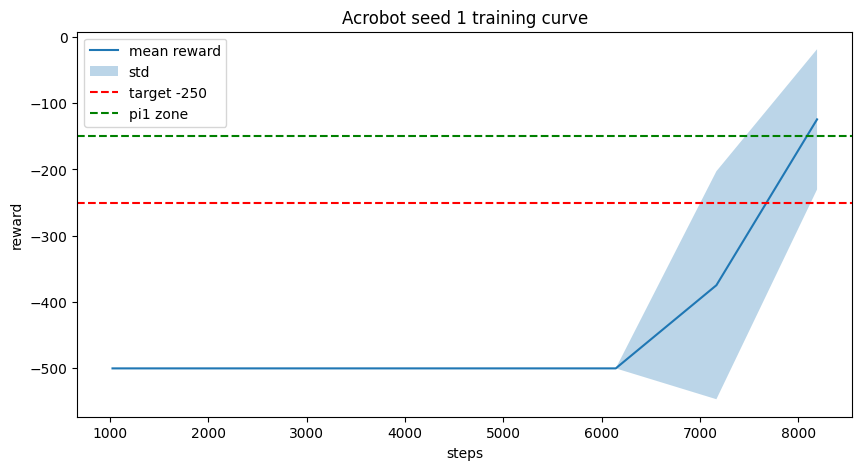

In [18]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

env_train.reset(seed=1)
env_eval.reset(seed=10_000 + 1)

checkpoint_interval = 1024

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=1,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-250, color="red", linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 1 training curve")
plt.legend()
plt.show()

Finished silent training to 7168 steps


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


7296 steps: -223.3 +/- 178.2
7424 steps: -256.8 +/- 189.8
7552 steps: -197.3 +/- 162.7
7680 steps: -251.6 +/- 183.1
7808 steps: -287.4 +/- 189.2
7936 steps: -343.9 +/- 192.6
8064 steps: -318.9 +/- 194.9
8192 steps: -284.3 +/- 193.6
8320 steps: -201.1 +/- 159.8
8448 steps: -147.4 +/- 115.5
Too good, stopping


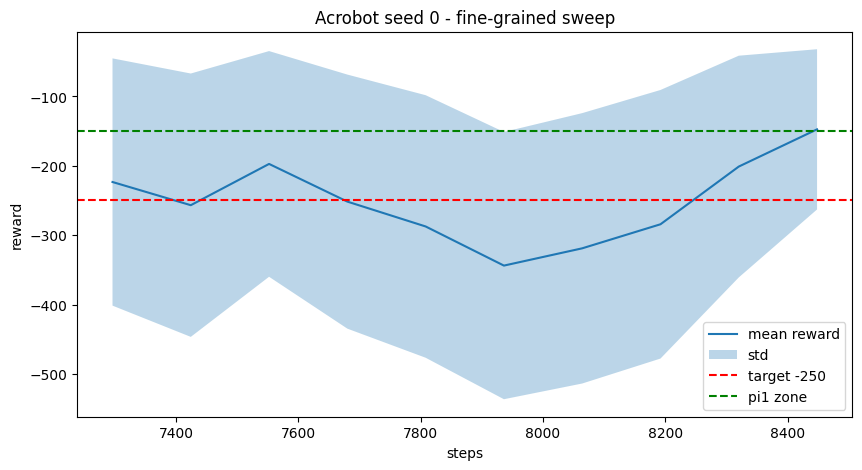

In [20]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

env_train.reset(seed=1)
env_eval.reset(seed=10_000 + 1)

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=1,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

# train silently to the interesting zone
model.learn(total_timesteps=7168, reset_num_timesteps=True)
total_steps = 7168
print(f"Finished silent training to {total_steps} steps")

# fine-grained sweep from 7168 onwards
for _ in range(0, 2_000, 128):
    model.learn(
        total_timesteps=128,
        reset_num_timesteps=False
    )
    total_steps += 128
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print("Too good, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-250, color="red", linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 0 - fine-grained sweep")
plt.legend()
plt.show()

## Seed 2 fine-grained sweep

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


1024 steps: -500.0 +/- 0.0
2048 steps: -500.0 +/- 0.0
3072 steps: -500.0 +/- 0.0
4096 steps: -500.0 +/- 0.0
5120 steps: -500.0 +/- 0.0
6144 steps: -500.0 +/- 0.0
7168 steps: -500.0 +/- 0.0
8192 steps: -500.0 +/- 0.0
9216 steps: -500.0 +/- 0.0
10240 steps: -500.0 +/- 0.0
11264 steps: -500.0 +/- 0.0
12288 steps: -436.4 +/- 146.3
13312 steps: -500.0 +/- 0.0
14336 steps: -500.0 +/- 0.0
15360 steps: -370.2 +/- 187.2
16384 steps: -314.6 +/- 201.8
17408 steps: -218.5 +/- 187.0
18432 steps: -202.8 +/- 174.7
19456 steps: -196.2 +/- 177.4
20480 steps: -326.0 +/- 201.8
21504 steps: -373.1 +/- 188.5
22528 steps: -331.1 +/- 199.7
23552 steps: -242.3 +/- 191.7
24576 steps: -151.9 +/- 146.9
25600 steps: -167.1 +/- 167.3
26624 steps: -132.4 +/- 121.2
Policy is now too good at 26624 steps, stopping


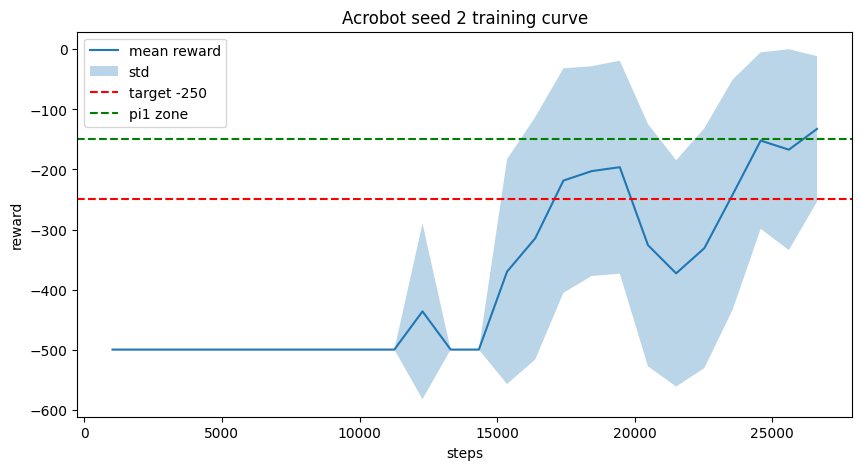

In [5]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

env_train.reset(seed=2)
env_eval.reset(seed=10_000 + 2)

checkpoint_interval = 1024

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=2,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-250, color="red", linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 2 training curve")
plt.legend()
plt.show()

## Seed 3 fine-grained sweep

### loaded checkpoints from steps 15360
- used smaller interval steps but results are bot satisfiying

In [11]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

for checkpoint_interval in [256, 128]:
    print(f"\n=== checkpoint_interval={checkpoint_interval} ===")
    for seed, start_steps, start_checkpoint in [
        (3, 15360, "acrobot_seed3_15360steps"),
    ]:
        print(f"\n--- seed {seed} ---")
        model = PPO.load(os.path.join(save_path, start_checkpoint), env=env_train)
        total_steps = start_steps

        for _ in range(0, 10_000, checkpoint_interval):
            model.learn(
                total_timesteps=checkpoint_interval,
                reset_num_timesteps=False
            )
            total_steps += checkpoint_interval
            mean_reward, std_reward = evaluate_policy(
                model,
                env_eval,
                n_eval_episodes=100,
                deterministic=True
            )
            print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

            if mean_reward > -150:
                print(f"Too good, stopping")
                break


=== checkpoint_interval=256 ===

--- seed 3 ---
15616 steps: -176.2 +/- 80.3
15872 steps: -131.3 +/- 29.5
Too good, stopping

=== checkpoint_interval=128 ===

--- seed 3 ---
15488 steps: -168.3 +/- 59.2
15616 steps: -138.3 +/- 47.8
Too good, stopping


### loaded checkpoints from steps 14336
- used smaller interval steps but results are bot satisfiying

In [12]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

for checkpoint_interval in [256, 128]:
    print(f"\n=== checkpoint_interval={checkpoint_interval} ===")
    for seed, start_steps, start_checkpoint in [
        (3, 14336, "acrobot_seed3_15360steps"),
    ]:
        print(f"\n--- seed {seed} ---")
        model = PPO.load(os.path.join(save_path, start_checkpoint), env=env_train)
        total_steps = start_steps

        for _ in range(0, 10_000, checkpoint_interval):
            model.learn(
                total_timesteps=checkpoint_interval,
                reset_num_timesteps=False
            )
            total_steps += checkpoint_interval
            mean_reward, std_reward = evaluate_policy(
                model,
                env_eval,
                n_eval_episodes=100,
                deterministic=True
            )
            print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

            if mean_reward > -150:
                print(f"Too good, stopping")
                break


=== checkpoint_interval=256 ===

--- seed 3 ---
14592 steps: -173.8 +/- 88.2
14848 steps: -141.1 +/- 50.8
Too good, stopping

=== checkpoint_interval=128 ===

--- seed 3 ---
14464 steps: -155.8 +/- 45.7
14592 steps: -138.9 +/- 57.8
Too good, stopping


### Retrained from scratch to understand if checkpoint loading is an issue

In [13]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")
checkpoint_interval = 1024

model = PPO(
      "MlpPolicy",
      env_train,
      verbose=0,
      device="cpu",
      seed=3,
      learning_rate=1e-4,
      n_steps=256,
      batch_size=64,
      n_epochs=5,
      ent_coef=0.01,
      gamma=0.99,
  )
total_steps = 0
for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    score = abs(mean_reward - target) + 0.25 * std_reward
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    # save every checkpoint
    # model.save(os.path.join(save_path, f"acrobot_seed{seed}_{total_steps}steps"))

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

1024 steps: -500.0 +/- 0.0
2048 steps: -500.0 +/- 0.0
3072 steps: -500.0 +/- 0.0
4096 steps: -500.0 +/- 0.0
5120 steps: -500.0 +/- 0.0
6144 steps: -500.0 +/- 0.0
7168 steps: -500.0 +/- 0.0
8192 steps: -500.0 +/- 0.0
9216 steps: -500.0 +/- 0.0
10240 steps: -500.0 +/- 0.0
11264 steps: -500.0 +/- 0.0
12288 steps: -500.0 +/- 0.0
13312 steps: -500.0 +/- 0.0
14336 steps: -500.0 +/- 0.0
15360 steps: -296.3 +/- 158.9
16384 steps: -147.8 +/- 49.0
Policy is now too good at 16384 steps, stopping


Finished silent training to 14336 steps
14464 steps: -490.2 +/- 55.9
14592 steps: -483.4 +/- 72.5
14720 steps: -437.7 +/- 124.4
14848 steps: -287.2 +/- 154.4
14976 steps: -223.9 +/- 120.1
15104 steps: -166.9 +/- 85.4
15232 steps: -143.7 +/- 56.0
Too good, stopping


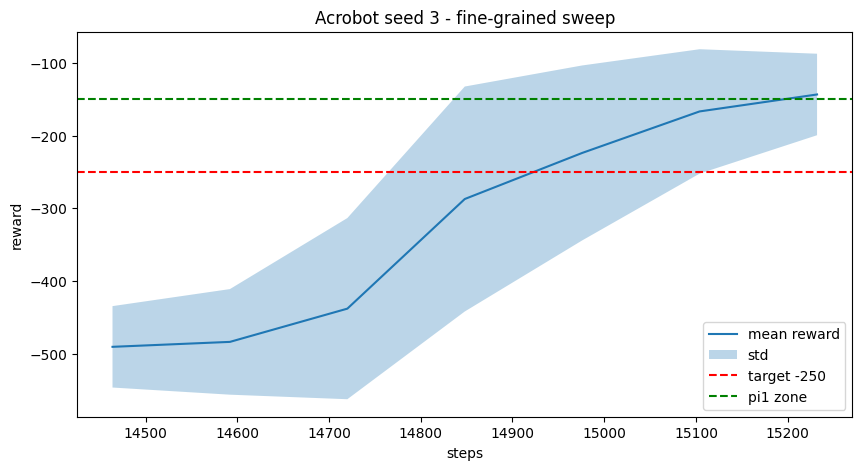

In [15]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=3,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

# train silently to the interesting zone
model.learn(total_timesteps=14_336, reset_num_timesteps=True)
total_steps = 14_336
print(f"Finished silent training to {total_steps} steps")

# fine-grained sweep from 14336 onwards
for _ in range(0, 2_000, 128):
    model.learn(
        total_timesteps=128,
        reset_num_timesteps=False
    )
    total_steps += 128
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print("Too good, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-250, color="red", linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 3 - fine-grained sweep")
plt.legend()
plt.show()

## Seed 4 fine-grained sweep

1024 steps: -291.4 +/- 182.3
2048 steps: -142.3 +/- 32.2
Policy is now too good at 2048 steps, stopping


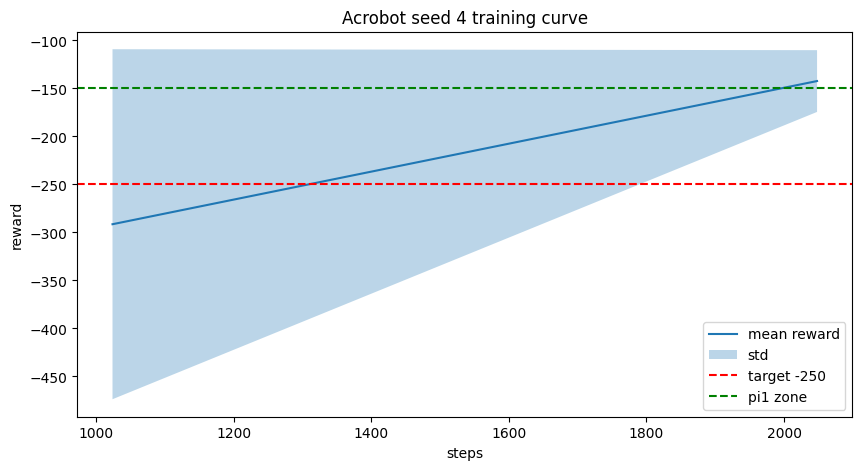

In [7]:
env_train = gym.make("Acrobot-v1")
env_eval = gym.make("Acrobot-v1")

env_train.reset(seed=4)
env_eval.reset(seed=10_000 + 4)

checkpoint_interval = 1024

steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=4,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -150:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-250, color="red", linestyle="--", label="target -250")
plt.axhline(-150, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("Acrobot seed 4 training curve")
plt.legend()
plt.show()

# MountainCar-v0

## Seed 0 fine-grained sweep

In [16]:
env_train = gym.make("MountainCar-v0")
env_eval = gym.make("MountainCar-v0")

checkpoint_interval = 1024
steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > -120:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(-155, color="red", linestyle="--", label="target ~-155")
plt.axhline(-120, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("MountainCar seed 0 training curve")
plt.legend()
plt.show()

1024 steps: -200.0 +/- 0.0
2048 steps: -200.0 +/- 0.0
3072 steps: -200.0 +/- 0.0
4096 steps: -200.0 +/- 0.0
5120 steps: -200.0 +/- 0.0
6144 steps: -200.0 +/- 0.0
7168 steps: -200.0 +/- 0.0
8192 steps: -200.0 +/- 0.0
9216 steps: -200.0 +/- 0.0
10240 steps: -200.0 +/- 0.0
11264 steps: -200.0 +/- 0.0
12288 steps: -200.0 +/- 0.0
13312 steps: -200.0 +/- 0.0
14336 steps: -200.0 +/- 0.0
15360 steps: -200.0 +/- 0.0
16384 steps: -200.0 +/- 0.0
17408 steps: -200.0 +/- 0.0
18432 steps: -200.0 +/- 0.0
19456 steps: -200.0 +/- 0.0
20480 steps: -200.0 +/- 0.0
21504 steps: -200.0 +/- 0.0
22528 steps: -200.0 +/- 0.0
23552 steps: -200.0 +/- 0.0
24576 steps: -200.0 +/- 0.0
25600 steps: -200.0 +/- 0.0
26624 steps: -200.0 +/- 0.0
27648 steps: -200.0 +/- 0.0
28672 steps: -200.0 +/- 0.0
29696 steps: -200.0 +/- 0.0
30720 steps: -200.0 +/- 0.0
31744 steps: -200.0 +/- 0.0
32768 steps: -200.0 +/- 0.0
33792 steps: -200.0 +/- 0.0
34816 steps: -200.0 +/- 0.0
35840 steps: -200.0 +/- 0.0
36864 steps: -200.0 +/- 0.0
3

KeyboardInterrupt: 

# MountainCarContinuous-v0

## Seed 0 fine-grained sweep

In [18]:
env_train = gym.make("MountainCarContinuous-v0")
env_eval = gym.make("MountainCarContinuous-v0")

checkpoint_interval = 2048
steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 80:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(45, color="red", linestyle="--", label="target ~45")
plt.axhline(80, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("MountainCarContinuous seed 0 training curve")
plt.legend()
plt.show()

2048 steps: -0.0 +/- 0.0
4096 steps: -0.0 +/- 0.0
6144 steps: -0.5 +/- 0.0
8192 steps: -5.8 +/- 0.0
10240 steps: -12.5 +/- 0.0
12288 steps: -7.1 +/- 0.0
14336 steps: -6.8 +/- 0.0
16384 steps: -5.8 +/- 0.0
18432 steps: -1.3 +/- 0.0
20480 steps: -0.9 +/- 0.0
22528 steps: -0.1 +/- 0.0
24576 steps: -0.1 +/- 0.0
26624 steps: -0.0 +/- 0.0
28672 steps: -0.0 +/- 0.0
30720 steps: -0.0 +/- 0.0
32768 steps: -0.2 +/- 0.0
34816 steps: -0.1 +/- 0.0
36864 steps: -0.0 +/- 0.0
38912 steps: -0.0 +/- 0.0
40960 steps: -0.1 +/- 0.0
43008 steps: -0.0 +/- 0.0
45056 steps: -0.1 +/- 0.0
47104 steps: -0.0 +/- 0.0


KeyboardInterrupt: 

In [19]:
env_train = gym.make("MountainCarContinuous-v0")
env_eval = gym.make("MountainCarContinuous-v0")

checkpoint_interval = 2048
steps_log = []
mean_log = []
std_log = []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=0,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.1,
    gamma=0.99,
)
total_steps = 0

for _ in range(0, 200_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model,
        env_eval,
        n_eval_episodes=100,
        deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    if mean_reward > 80:
        print(f"Policy is now too good at {total_steps} steps, stopping")
        break

plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(steps_log,
                 [m - s for m, s in zip(mean_log, std_log)],
                 [m + s for m, s in zip(mean_log, std_log)],
                 alpha=0.3, label="std")
plt.axhline(45, color="red", linestyle="--", label="target ~45")
plt.axhline(80, color="green", linestyle="--", label="pi1 zone")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title("MountainCarContinuous seed 0 training curve")
plt.legend()
plt.show()

2048 steps: -0.0 +/- 0.0
4096 steps: -0.0 +/- 0.0
6144 steps: -0.4 +/- 0.0
8192 steps: -6.1 +/- 0.0
10240 steps: -14.1 +/- 0.0
12288 steps: -8.9 +/- 0.0
14336 steps: -8.5 +/- 0.0
16384 steps: -6.7 +/- 0.0
18432 steps: -1.9 +/- 0.0
20480 steps: -1.0 +/- 0.0
22528 steps: -0.2 +/- 0.0
24576 steps: -0.1 +/- 0.0
26624 steps: -0.1 +/- 0.0
28672 steps: -0.0 +/- 0.0
30720 steps: -0.0 +/- 0.0
32768 steps: -0.3 +/- 0.0
34816 steps: -0.2 +/- 0.0
36864 steps: -0.1 +/- 0.0
38912 steps: -0.0 +/- 0.0
40960 steps: -0.1 +/- 0.0
43008 steps: -0.0 +/- 0.0
45056 steps: -0.1 +/- 0.0
47104 steps: -0.0 +/- 0.0
49152 steps: -0.0 +/- 0.0
51200 steps: -0.0 +/- 0.0
53248 steps: -0.0 +/- 0.0
55296 steps: -0.0 +/- 0.0
57344 steps: -0.0 +/- 0.0
59392 steps: -0.0 +/- 0.0
61440 steps: -0.0 +/- 0.0
63488 steps: -0.1 +/- 0.0
65536 steps: -0.0 +/- 0.0
67584 steps: -0.0 +/- 0.0
69632 steps: -0.0 +/- 0.0
71680 steps: -0.0 +/- 0.0
73728 steps: -0.0 +/- 0.0
75776 steps: -0.0 +/- 0.0
77824 steps: -0.0 +/- 0.0
79872 steps: -0

KeyboardInterrupt: 